# **Evaluasi Model (Klasifikasi Time Series - Dataset BME)**

In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix)
import matplotlib. pyplot as plt
import seaborn as sns
import joblib

df_train = pd.read_csv('BME_TRAIN.csv')
df_test = pd.read_csv('BME_TEST.csv')

X_train = df_train.drop('target', axis=1)
y_train = df_train['target']
X_test = df_test.drop('target', axis=1)
y_test = df_test['target']

def handle_outliers_winsorization(data):
    data_copy = data.copy()
    
    Q1 = data_copy.quantile(0.25)
    Q3 = data_copy.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Capping: nilai di bawah lower_bound diganti dengan lower_bound
    #          nilai di atas upper_bound diganti dengan upper_bound
    for col in data_copy.columns:
        data_copy[col] = data_copy[col].clip(lower=lower_bound[col], upper=upper_bound[col])
    
    return data_copy

X_train = handle_outliers_winsorization(X_train)
X_test = handle_outliers_winsorization(X_test)

scaler = joblib.load('scaler_bme.pkl')
best_model = joblib. load('model_rf_bme.pkl')

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 5.1 Prediksi pada data test

In [2]:
y_pred = best_model.predict(X_test_scaled)

print("Hasil Prediksi vs Aktual:")
comparison_df = pd.DataFrame({
    'Aktual': y_test. values,
    'Prediksi': y_pred,
    'Benar': y_test.values == y_pred
})
print(comparison_df.to_string(index=False))

Hasil Prediksi vs Aktual:
 Aktual  Prediksi  Benar
      1         1   True
      2         2   True
      3         3   True
      1         1   True
      2         2   True
      2         2   True
      1         1   True
      3         3   True


### 5.2 Metrik Evaluasi

In [3]:
accuracy = accuracy_score(y_test, y_pred)
precision_macro = precision_score(y_test, y_pred, average='macro')
precision_weighted = precision_score(y_test, y_pred, average='weighted')
recall_macro = recall_score(y_test, y_pred, average='macro')
recall_weighted = recall_score(y_test, y_pred, average='weighted')
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"\nPrecision (Macro): {precision_macro:.4f}")
print(f"Precision (Weighted): {precision_weighted:.4f}")
print(f"\nRecall (Macro): {recall_macro:.4f}")
print(f"Recall (Weighted): {recall_weighted:.4f}")
print(f"\nF1-Score (Macro): {f1_macro:.4f}")
print(f"F1-Score (Weighted): {f1_weighted:.4f}")

Accuracy: 1.0000

Precision (Macro): 1.0000
Precision (Weighted): 1.0000

Recall (Macro): 1.0000
Recall (Weighted): 1.0000

F1-Score (Macro): 1.0000
F1-Score (Weighted): 1.0000


### 5.3 Classification Report

In [4]:
target_names = ['Begin (1)', 'Middle (2)', 'End (3)']
print(classification_report(y_test, y_pred, target_names=target_names))

              precision    recall  f1-score   support

   Begin (1)       1.00      1.00      1.00         3
  Middle (2)       1.00      1.00      1.00         3
     End (3)       1.00      1.00      1.00         2

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



### 5.4 Confusion Matrix

Confusion Matrix:
[[3 0 0]
 [0 3 0]
 [0 0 2]]


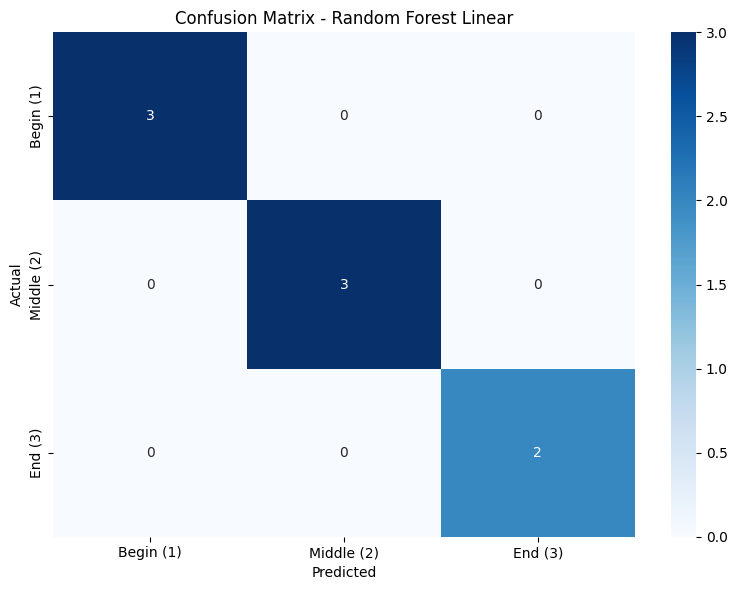

In [5]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, 
            yticklabels=target_names)
plt. title('Confusion Matrix - Random Forest Linear')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt. tight_layout()
plt.show()

### 5.5 Ringkasan Evaluasi

           Metrik  Nilai
         Accuracy    1.0
Precision (Macro)    1.0
   Recall (Macro)    1.0
 F1-Score (Macro)    1.0


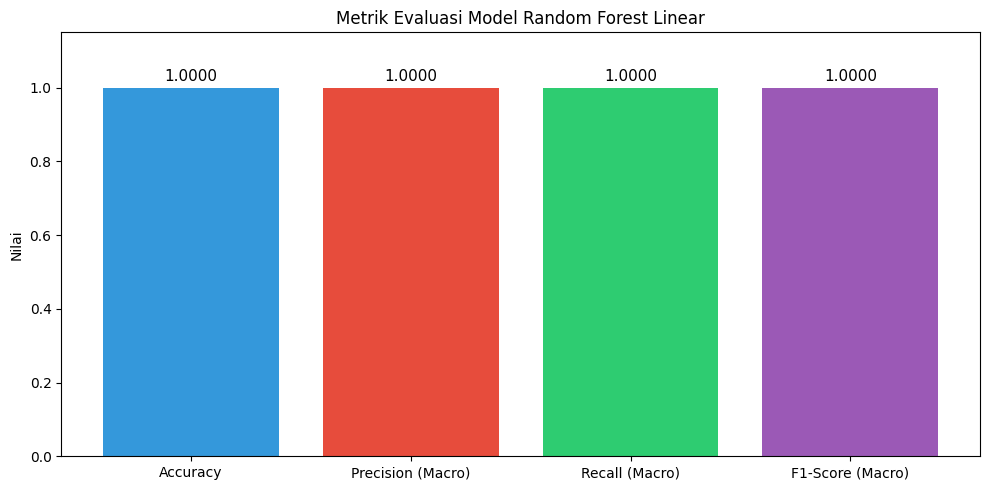

In [6]:
summary_df = pd.DataFrame({
    'Metrik': ['Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1-Score (Macro)'],
    'Nilai': [accuracy, precision_macro, recall_macro, f1_macro]
})
print(summary_df.to_string(index=False))

plt.figure(figsize=(10, 5))
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']
bars = plt.bar(summary_df['Metrik'], summary_df['Nilai'], color=colors)

for bar, val in zip(bars, summary_df['Nilai']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{val:.4f}', ha='center', va='bottom', fontsize=11)

plt.ylim(0, 1.15)
plt.ylabel('Nilai')
plt.title('Metrik Evaluasi Model Random Forest Linear')
plt.tight_layout()
plt.show()